# Figure 3 notebook

This notebook consolidates the analysis and plotting steps previously split across:

- `Archive/03d_Viz_Geoms.ipynb`
- `04e_opt_cell_subclass_correspondence_clean.ipynb`
- `04f_Viz_correspondance_colorpleth.ipynb`

The goal is to produce a coherent, public-facing workflow that recreates the figure panels and assembles a layout mock for `Figure3`.

## What this notebook does

1. Loads the `TissueMultiGraph` object and the cell-layer h5ad file.
2. Recreates individual panels (`a` through `h`):
   - **a, b** — Representative coronal sections colored by subclass (a) and optimized taxonomy (b).
   - **c** — CDF of cell-type sizes comparing subclass and opt_cell taxonomies.
   - **d** — Sankey/stacked-bar chart of correspondence topology between opt_cell and subclass.
   - **e** — Boxplot of subclass size distributions across correspondence categories.
   - **f** — Colorpleth map highlighting the seven optimized oligodendrocyte-derived types.
   - **g** — Colorpleth map of the oligodendrocyte subclass for comparison.
   - **h** — Stacked area plot of optimized oligodendrocyte type abundances across sections.
3. Saves each panel into `Figures/`.
4. Assembles a final composite mock figure.

This notebook assumes the project is run from either the repository root or the `Notebooks/` directory.

In [1]:
import os
import sys
from pathlib import Path

import colorcet as cc
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MPath

ROOT = Path.cwd().resolve()
if not (ROOT / "Data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "Data"
FIG_DIR = ROOT / "Figures"
os.makedirs(FIG_DIR, exist_ok=True)

for repo_path in [ROOT / "Repos" / "TMG", ROOT / "Repos" / "max_info_atlas" / "src"]:
    repo_str = str(repo_path)
    if repo_str not in sys.path:
        sys.path.insert(0, repo_str)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": False,
        "savefig.facecolor": "white",
        "font.size": 10,
    }
)

PANEL_PATHS = {
    "a":    FIG_DIR / "Figure3_panel_a.png",
    "b":    FIG_DIR / "Figure3_panel_b.png",
    "c":    FIG_DIR / "Figure3_panel_c.png",
    "d":    FIG_DIR / "Figure3_panel_d.png",
    "e":    FIG_DIR / "Figure3_panel_e.png",
    "f":    FIG_DIR / "Figure3_panel_f.png",
    "g":    FIG_DIR / "Figure3_panel_g.png",
    "h":    FIG_DIR / "Figure3_panel_h.png",
    "mock": FIG_DIR / "Figure3_mock.png",
}


def show_image(ax, image_path):
    image = plt.imread(image_path)
    ax.imshow(image)
    ax.set_axis_off()


def add_panel_label(ax, label):
    ax.text(
        -0.06,
        1.03,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top",
        ha="right",
    )

## Load the TMG object

The TMG object (with geometries) is used for panels `a`, `b`, `f`, `g`, and `h`.

In [2]:
from TMG.Analysis.TissueGraph import TissueMultiGraph
from TMG.Visualization import Viz
from TMG.Visualization.Viz import SingleMapView

tmg_path = DATA_DIR / "MouseBrainTMG"
TMG = TissueMultiGraph(basepath=str(tmg_path))
TMG.load_geoms()
sections = list(TMG.unqS)

SubclassTx = TMG.get_tax("subclass")
OptCellTx = TMG.get_tax("opt_cell")

example_section = next(sec for sec in TMG.unqS if str(sec).endswith(".36"))
original_cell_tax = TMG.layer_taxonomy_mapping[0]

print(f"Loaded TMG from: {tmg_path}")
print(f"n_sections = {len(TMG.unqS)}")
print(f"example_section = {example_section}")

Loaded TMG from: /home/rwollman/MyProjects/MaxInfoCart/Data/MouseBrainTMG
n_sections = 59
example_section = C57BL6J-638850.36


## Panels a and b: coronal section under subclass and optimized taxonomies

Panel `a` colors cells by the BICCN subclass taxonomy. Panel `b` colors the same section using the spatially optimized cell-type taxonomy.

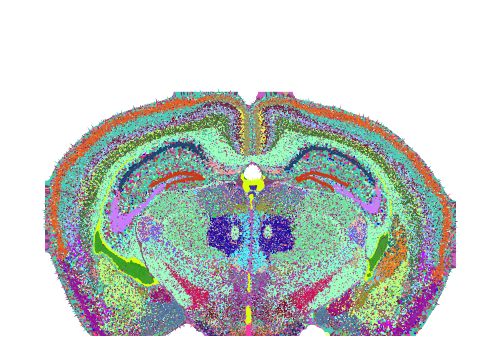

Saved panel a: /home/rwollman/MyProjects/MaxInfoCart/Figures/Figure3_panel_a.png


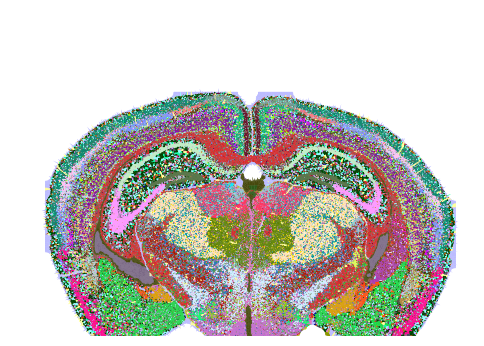

Saved panel b: /home/rwollman/MyProjects/MaxInfoCart/Figures/Figure3_panel_b.png


In [3]:
def add_cell_typemap(view, section, tax_name, pos, title):
    TMG.update_current_type(0, tax_name)
    panel = Viz.TypeMap(
        geom_type=TMG.layer_to_geom_type_mapping["cell"],
        V=view,
        section=section,
        pos=pos,
        name=title,
        rotation=180,
    )
    view.Panels.append(panel)
    return panel


for tax_name, panel_key in [("subclass", "a"), ("opt_cell", "b")]:
    view = Viz.View(TMG, name=f"{example_section} {tax_name}", figsize=(6, 6))
    gs = view.fig.add_gridspec(1, 1)
    add_cell_typemap(view, example_section, tax_name, gs[0, 0], tax_name)
    view.show()
    view.Panels[0].ax.set_title("")
    plt.show()
    view.fig.savefig(PANEL_PATHS[panel_key], dpi=300, bbox_inches="tight")
    print(f"Saved panel {panel_key}: {PANEL_PATHS[panel_key]}")

TMG.update_current_type(0, original_cell_tax)

## Load cell-layer data for correspondence analysis

Panels `c`, `d`, and `e` are derived from the contingency table between `opt_cell` and `subclass` labels stored in the h5ad file.

In [4]:
DATA_PATH = DATA_DIR / "MouseBrainTMG" / "Layer" / "cell_layer.h5ad"


def decode_categories(values):
    return np.array(
        [v.decode("utf-8") if isinstance(v, bytes) else str(v) for v in values]
    )


with h5py.File(DATA_PATH, "r") as handle:
    opt_values     = handle["obs"]["opt_cell"][:].astype(np.int32)
    subclass_codes = handle["obs"]["subclass"]["codes"][:].astype(np.int32)
    subclass_names = decode_categories(handle["obs"]["subclass"]["categories"][:])
    class_codes    = handle["obs"]["class"]["codes"][:].astype(np.int32)
    class_names    = decode_categories(handle["obs"]["class"]["categories"][:])

opt_unique  = np.unique(opt_values)
opt_lookup  = np.empty(opt_unique.max() + 1, dtype=np.int32)
opt_lookup[opt_unique] = np.arange(opt_unique.size, dtype=np.int32)
opt_codes   = opt_lookup[opt_values]

n_cells    = opt_codes.size
n_opt      = opt_unique.size
n_subclass = subclass_names.size
n_class    = class_names.size

print(f"cells={n_cells:,}  opt_cell={n_opt}  subclass={n_subclass}  class={n_class}")


def build_contingency(source_codes, target_codes, n_source, n_target):
    flat = np.bincount(
        source_codes * n_target + target_codes, minlength=n_source * n_target
    )
    return flat.reshape(n_source, n_target)


def normalized_views(contingency):
    row_sums = contingency.sum(axis=1, keepdims=True)
    col_sums = contingency.sum(axis=0, keepdims=True)
    row_norm = np.divide(
        contingency, row_sums,
        out=np.zeros_like(contingency, dtype=float), where=row_sums > 0
    )
    col_norm = np.divide(
        contingency, col_sums,
        out=np.zeros_like(contingency, dtype=float), where=col_sums > 0
    )
    return row_norm, col_norm


opt_subclass_ct = build_contingency(opt_codes, subclass_codes, n_opt, n_subclass)
opt_row_norm, subclass_col_norm = normalized_views(opt_subclass_ct)

cells=3,936,930  opt_cell=165  subclass=338  class=34


## Panel c: cumulative distribution of cell-type sizes

Comparing the distribution of cells per type between the BICCN subclass taxonomy and the optimized taxonomy.

In [1]:
subclass_cnt = opt_subclass_ct.sum(axis=0)
opt_cnt      = opt_subclass_ct.sum(axis=1)

fig, ax = plt.subplots(figsize=(2, 2))
ax.plot(np.sort(subclass_cnt), np.cumsum(np.sort(subclass_cnt))/opt_cnt.sum() , "-")
ax.plot(np.sort(opt_cnt),      np.cumsum(np.sort(opt_cnt))/opt_cnt.sum()    , "-")
ax.grid(False)
xticks = ax.get_xticks()
ax.set_xticks(xticks)
ax.set_xticklabels([f"{int(x/1000)}" for x in xticks], fontsize=6)
ax.tick_params(axis='y', labelsize=6)
ax.set_xlim((-1000, 600000))
ax.set_xlabel("Fraction of total cells", fontsize=7)
ax.set_ylabel("Total cells $x10^6$", fontsize=7)
for spine in ax.spines.values():
    spine.set_visible(True)
plt.tight_layout()
fig.savefig(PANEL_PATHS["c"], dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'opt_subclass_ct' is not defined

## Panel d: correspondence topology between opt_cell and subclass

Each cluster is assigned to one of four categories using the bidirectional 66% coverage rule:
one-to-one, one-to-many, many-to-one, and many-to-many. The Sankey-style stacked bar
summarises type-level correspondence between the two taxonomies.

In [6]:
coverage_threshold = 0.66

opt_to_subclasses = {}
for oi in range(n_opt):
    row   = opt_row_norm[oi]
    order = np.argsort(row)[::-1]
    nz    = order[row[order] > 0]
    k     = np.searchsorted(np.cumsum(row[nz]), coverage_threshold, side="left") + 1
    opt_to_subclasses[oi] = nz[:k].tolist()

subclass_to_opts = {}
for sj in range(n_subclass):
    col   = subclass_col_norm[:, sj]
    order = np.argsort(col)[::-1]
    nz    = order[col[order] > 0]
    k     = np.searchsorted(np.cumsum(col[nz]), coverage_threshold, side="left") + 1
    subclass_to_opts[sj] = nz[:k].tolist()

opt_topo = []
for oi in range(n_opt):
    S_i   = opt_to_subclasses[oi]
    k_sub = len(S_i)
    if k_sub == 1:
        sj    = S_i[0]
        O_j   = subclass_to_opts[sj]
        k_opt = len(O_j)
        if k_opt == 1 and O_j[0] == oi:
            cat = "1-to-1"
        elif k_opt > 1 and all(
            len(opt_to_subclasses[oi2]) == 1 and opt_to_subclasses[oi2][0] == sj
            for oi2 in O_j
        ):
            cat = "many-to-1"
        else:
            cat = "many-to-many"
    else:
        cat = "1-to-many" if all(
            len(subclass_to_opts[sj]) == 1 and subclass_to_opts[sj][0] == oi
            for sj in S_i
        ) else "many-to-many"
    opt_topo.append(cat)

subclass_topo = []
for sj in range(n_subclass):
    O_j   = subclass_to_opts[sj]
    k_opt = len(O_j)
    if k_opt == 1:
        oi    = O_j[0]
        S_i   = opt_to_subclasses[oi]
        k_sub = len(S_i)
        if k_sub == 1 and S_i[0] == sj:
            cat = "1-to-1"
        elif k_sub > 1 and all(
            len(subclass_to_opts[sj2]) == 1 and subclass_to_opts[sj2][0] == oi
            for sj2 in S_i
        ):
            cat = "1-to-many"
        else:
            cat = "many-to-many"
    else:
        cat = "many-to-1" if all(
            len(opt_to_subclasses[oi]) == 1 and opt_to_subclasses[oi][0] == sj
            for oi in O_j
        ) else "many-to-many"
    subclass_topo.append(cat)

cat_order = ["1-to-1", "1-to-many", "many-to-1", "many-to-many"]
opt_topo_series      = pd.Series(opt_topo,      index=opt_unique,     name="topology")
subclass_topo_series = pd.Series(subclass_topo, index=subclass_names, name="topology")
opt_counts = opt_topo_series.value_counts().reindex(cat_order, fill_value=0)
sub_counts = subclass_topo_series.value_counts().reindex(cat_order, fill_value=0)

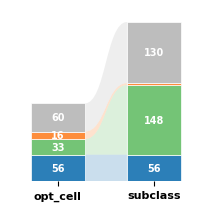

In [7]:
cat_colors = ["#2C7FB8", "#74C476", "#FD8D3C", "#BDBDBD"]

opt_vals = opt_counts.values.astype(float)
sub_vals = sub_counts.values.astype(float)
max_val  = max(opt_vals.sum(), sub_vals.sum())

fig, ax = plt.subplots(figsize=(2, 2))
bar_w, x_opt, x_sub = 0.28, 0.25, 0.75
opt_bottom = sub_bottom = 0.0

for color, ov, sv in zip(cat_colors, opt_vals, sub_vals):
    ax.bar(x_opt, ov, width=bar_w, bottom=opt_bottom, color=color, edgecolor="white", linewidth=0.5, zorder=3)
    ax.bar(x_sub, sv, width=bar_w, bottom=sub_bottom, color=color, edgecolor="white", linewidth=0.5, zorder=3)

    x0  = x_opt + bar_w / 2
    x1  = x_sub - bar_w / 2
    xm  = (x0 + x1) / 2
    verts = [
        (x0, opt_bottom), (xm, opt_bottom), (xm, sub_bottom), (x1, sub_bottom),
        (x1, sub_bottom + sv), (xm, sub_bottom + sv), (xm, opt_bottom + ov),
        (x0, opt_bottom + ov), (x0, opt_bottom),
    ]
    codes = [
        MPath.MOVETO, MPath.CURVE4, MPath.CURVE4, MPath.CURVE4,
        MPath.LINETO, MPath.CURVE4, MPath.CURVE4, MPath.CURVE4, MPath.CLOSEPOLY,
    ]
    ax.add_patch(PathPatch(MPath(verts, codes), facecolor=color, alpha=0.25, edgecolor="none", zorder=2))

    if ov > max_val * 0.03:
        ax.text(x_opt, opt_bottom + ov / 2, str(int(ov)), ha="center", va="center",
                fontsize=7, fontweight="bold", color="white", zorder=4)
    if sv > max_val * 0.03:
        ax.text(x_sub, sub_bottom + sv / 2, str(int(sv)), ha="center", va="center",
                fontsize=7, fontweight="bold", color="white", zorder=4)

    opt_bottom += ov
    sub_bottom += sv

ax.set_xlim(0, 1)
ax.set_ylim(0, max_val * 1.08)
ax.set_yticks([])
ax.set_xticks([x_opt, x_sub])
ax.set_xticklabels(["opt_cell", "subclass"], fontsize=8, fontweight="bold")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout(pad=0.3)
fig.savefig(PANEL_PATHS["d"], dpi=300, bbox_inches="tight")
plt.show()

## Panel e: cell-count distribution within each correspondence category

Boxplot of subclass sizes split by the four correspondence topology categories.

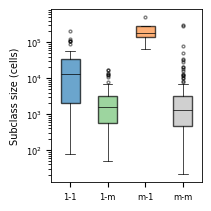

In [8]:
sub_sizes_by_cat = {
    cat: opt_subclass_ct.sum(axis=0)[np.array(subclass_topo) == cat]
    for cat in cat_order
}

fig, ax = plt.subplots(figsize=(2, 2), constrained_layout=True)

data = [sub_sizes_by_cat[cat] for cat in cat_order]

bp = ax.boxplot(
    data,
    positions=range(len(cat_order)),
    widths=0.5,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=0.5),
    whiskerprops=dict(linewidth=0.5),
    capprops=dict(linewidth=0.5),
    flierprops=dict(marker="o", markersize=2, alpha=0.5, linewidth=0),
)

for patch, color in zip(bp["boxes"], cat_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yscale("log")
ax.set_xticks(range(len(cat_order)))
ax.set_xticklabels(["1-1", "1-m", "m-1", "m-m"], fontsize=6)
ax.set_ylabel("Subclass size (cells)", fontsize=7)
ax.tick_params(axis="y", labelsize=6)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.6)
fig.savefig(PANEL_PATHS["e"], dpi=300, bbox_inches="tight")
plt.show()

## Panels f, g, h: spatial distribution of oligodendrocyte-derived types

Helper functions for discrete colorpleth maps.

In [9]:
BACKGROUND_RGBA = np.array(to_rgba("#d9d9d9"))


def taxonomy_palette(taxonomy, selected_type_ids, background_rgba=BACKGROUND_RGBA):
    """Build a discrete palette with code 0 reserved for background."""
    palette = [background_rgba]
    for type_id in selected_type_ids:
        palette.append(np.array(to_rgba(taxonomy.RGB[int(type_id)])))
    return np.vstack(palette)


def colorpleth_codes(type_values, selected_type_ids):
    """Map selected types to 1..N and everything else to 0."""
    code_map = {int(type_id): idx + 1 for idx, type_id in enumerate(selected_type_ids)}
    return np.array([code_map.get(int(type_id), 0) for type_id in type_values], dtype=int)


def show_discrete_colorpleth(
    section,
    taxonomy_name,
    selected_type_ids,
    title,
    figsize=(6, 6),
    palette=None,
    **kwargs,
):
    layer = TMG.Layers[0]
    TMG.update_current_type(0, taxonomy_name)
    section_mask  = layer.Section == section
    section_types = layer.Type[section_mask].astype(int)
    codes = colorpleth_codes(section_types, selected_type_ids)

    view = SingleMapView(
        TMG,
        section=section,
        level_type="cell",
        map_type="colorpleth",
        val_to_map=codes,
        figsize=figsize,
        axis_off=True,
        rotation=180,
        clim=(0, max(len(selected_type_ids), 1)),
        **kwargs,
    )

    if palette is None:
        palette = taxonomy_palette(TMG.get_tax(taxonomy_name), selected_type_ids)

    view.Panels[0].rgb_faces = palette[codes]
    view.show()

    ax = view.Panels[0].ax
    ax.set_title(title)
    return view, codes, palette

## Panel f: spatial map of oligodendrocyte-derived opt_cell types

The seven optimized types that collectively account for >90% of cells assigned to the oligodendrocyte subclass.

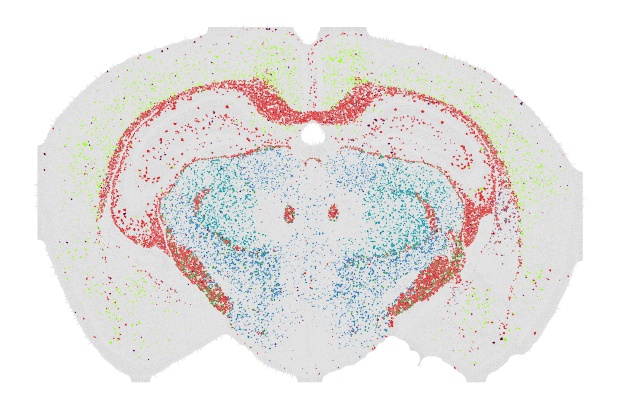

In [10]:
section_opt   = "C57BL6J-638850.36"
opt_match_oligo = [12, 26, 19, 60, 61, 15, 37]

opt_view, opt_codes, opt_palette = show_discrete_colorpleth(
    section=section_opt,
    taxonomy_name="opt_cell",
    selected_type_ids=opt_match_oligo,
    title="",
    figsize=(6, 6),
    antialiaseds=True,
)
opt_view.fig.savefig(PANEL_PATHS["f"], dpi=300, bbox_inches="tight")
plt.show()

## Panel g: spatial map of the oligodendrocyte subclass

The three subclasses that correspond to the seven opt_cell types above, shown in the same section.

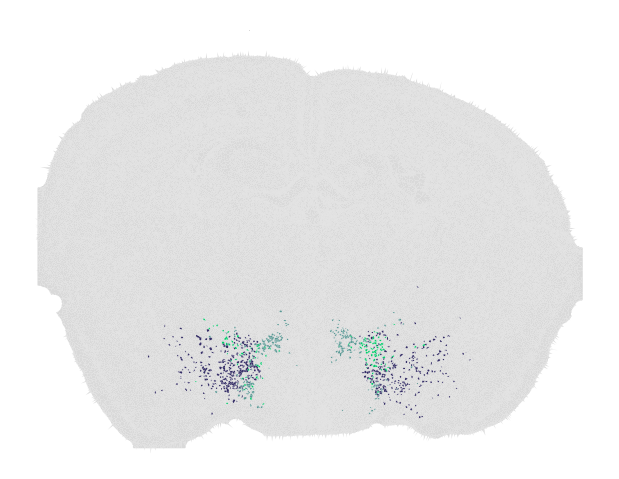

In [11]:
subcls_that_got_merged = [
    "119 SI-MA-LPO-LHA Skor1 Glut",
    "117 LHA Barhl2 Glut",
    "118 ADP-MPO Trp73 Glut",
]
subcls_that_got_merged_ix = SubclassTx.get_type_ix(subcls_that_got_merged)

section_subclass = "C57BL6J-638850.43"
subclass_view, subclass_codes, subclass_palette = show_discrete_colorpleth(
    section=section_subclass,
    taxonomy_name="subclass",
    selected_type_ids=subcls_that_got_merged_ix,
    title="",
    figsize=(6, 6),
)
subclass_view.fig.savefig(PANEL_PATHS["g"], dpi=300, bbox_inches="tight")
plt.show()

## Panel h: abundance of oligodendrocyte-derived types across sections

Stacked area plot showing the anterior-posterior abundance profile of the seven optimized oligodendrocyte cell types across all 59 coronal sections.

/tmp/ipykernel_379237/1047996391.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in yticklabels])


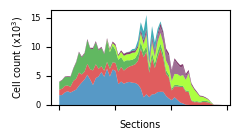

In [12]:
clrmp = opt_palette[1:, :].copy()
clrmp[:, 3] = 0.75

TMG.update_current_type(0, "subclass")
oligo_ix = SubclassTx.get_type_ix(["327 Oligo NN"])[0]
is_oligo_mask = TMG.Layers[0].Type == oligo_ix

TMG.update_current_type(0, "opt_cell")
sections_sorted = np.sort(TMG.Layers[0].Section.unique())
per_section_counts = pd.DataFrame(0, index=sections_sorted, columns=opt_match_oligo)

for opt_type in opt_match_oligo:
    mask = (TMG.Layers[0].Type == opt_type) & is_oligo_mask
    counts = TMG.Layers[0].Section[mask].value_counts()
    per_section_counts.loc[counts.index, opt_type] = counts.values

fig, ax = plt.subplots(figsize=(2.5, 1.5))
per_section_counts.plot.area(ax=ax, stacked=True, color=clrmp, linewidth=0)
ax.get_legend().remove()
ax.set_xlabel("Sections", fontsize=7)
ax.set_ylabel(r"Cell count (x$10^3$)", fontsize=7)
ax.set_xticklabels([])
ax.tick_params(axis="both", which="major", labelsize=6)
yticklabels = ax.get_yticks()
ax.set_yticklabels([f"{y/1000:.0f}" for y in yticklabels])
plt.tight_layout()
fig.savefig(PANEL_PATHS["h"], dpi=300, bbox_inches="tight")
plt.show()

TMG.update_current_type(0, original_cell_tax)

## Assemble the full figure mock

Arranges the saved panel PNGs into a single composite image following the organisation of the reference figure.

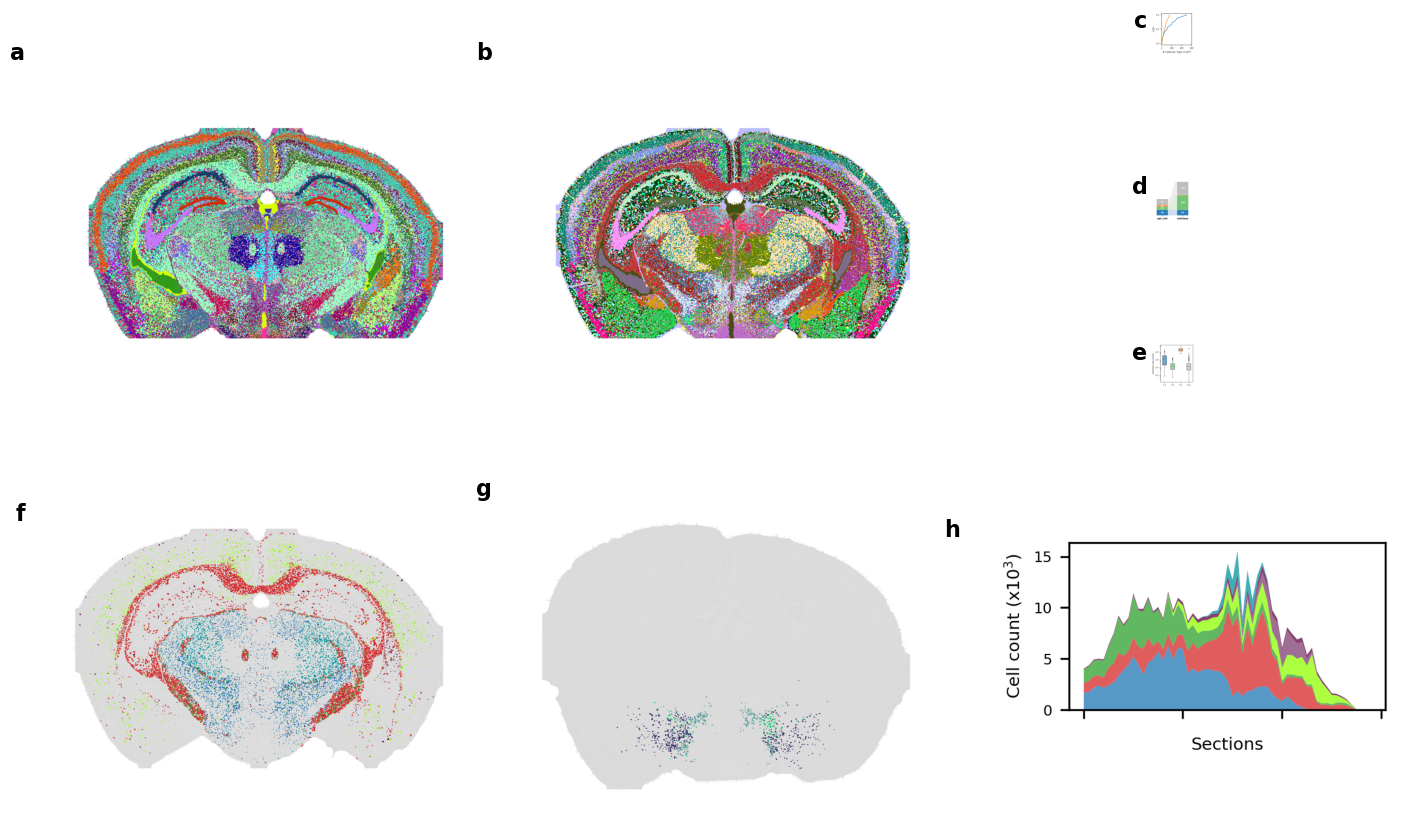

PosixPath('/home/rwollman/MyProjects/MaxInfoCart/Figures/Figure3_mock.png')

In [13]:
missing_panels = [key for key, path in PANEL_PATHS.items() if key != "mock" and not path.exists()]
if missing_panels:
    raise FileNotFoundError(f"Missing panel images: {missing_panels}")

fig = plt.figure(figsize=(14, 9), constrained_layout=True)
outer = fig.add_gridspec(
    nrows=3,
    ncols=3,
    height_ratios=[1.5, 1.0, 1.0],
    width_ratios=[1.0, 1.0, 1.0],
)

# Row 0: panels a and b (full-section views)
ax_a = fig.add_subplot(outer[0, 0])
show_image(ax_a, PANEL_PATHS["a"])
add_panel_label(ax_a, "a")

ax_b = fig.add_subplot(outer[0, 1])
show_image(ax_b, PANEL_PATHS["b"])
add_panel_label(ax_b, "b")

# Row 0, col 2: panels c, d, e stacked
right_col = outer[0, 2].subgridspec(3, 1, hspace=0.4)
ax_c = fig.add_subplot(right_col[0])
show_image(ax_c, PANEL_PATHS["c"])
add_panel_label(ax_c, "c")

ax_d = fig.add_subplot(right_col[1])
show_image(ax_d, PANEL_PATHS["d"])
add_panel_label(ax_d, "d")

ax_e = fig.add_subplot(right_col[2])
show_image(ax_e, PANEL_PATHS["e"])
add_panel_label(ax_e, "e")

# Row 1+2: panels f, g, h
ax_f = fig.add_subplot(outer[1:, 0])
show_image(ax_f, PANEL_PATHS["f"])
add_panel_label(ax_f, "f")

ax_g = fig.add_subplot(outer[1:, 1])
show_image(ax_g, PANEL_PATHS["g"])
add_panel_label(ax_g, "g")

ax_h = fig.add_subplot(outer[1:, 2])
show_image(ax_h, PANEL_PATHS["h"])
add_panel_label(ax_h, "h")

fig.savefig(PANEL_PATHS["mock"], dpi=300, bbox_inches="tight")
plt.show()

PANEL_PATHS["mock"]